# Welcome!

**This notebook gives a simple, hands-on introduction to Shimexpy.**

### Physical intuition (very brief)

In Spatial Harmonic Imaging (SHI), the raw X-ray intensity contains a periodic modulation produced by the projected grid. This modulation becomes a set of discrete spatial harmonics in the Fourier domain. From these harmonics, Shimexpy retrieves absorption, differential phase, and scattering contrasts.

We’ll load a small example dataset, extract the spatial harmonics, and reconstruct the three SHI contrasts step by step. The goal is to help you understand how the workflow fits together while keeping the code clean and easy to follow.

In [1]:
# Core scientific stack
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Some matplotlib parameters for "cool" visualization :)
plt.rcParams.update({
    "font.family": "serif",      
    "font.size": 10,             
    "axes.titlesize": 11,        
    "axes.labelsize": 10,        
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# All figures will be exported in
path2exp = Path("results") # Specify your directory to export
path2exp.mkdir(parents=True, exist_ok=True)

# Visualization helpers
from skimage.exposure import equalize_hist, rescale_intensity

def percentile_eq(image, p_low=2, p_high=98):
    """
    Contrast stretching based on percentiles p_low and p_high.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image (any numeric dtype).
    p_low : float
        Lower percentile (default = 2).
    p_high : float
        Upper percentile (default = 98).

    Returns
    -------
    np.ndarray
        Image rescaled after percentile stretching.
    """
    img = image.astype(np.float32)

    # Compute percentiles
    p2, p98 = np.percentile(img, (p_low, p_high))

    # Stretch
    img_stretched = rescale_intensity(img, in_range=(p2, p98))

    return img_stretched

## Loading data

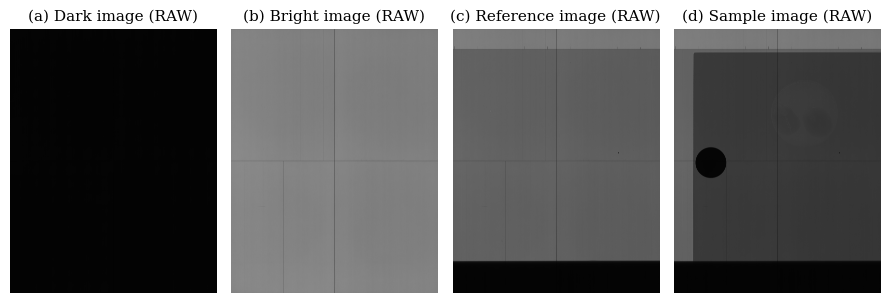

In [2]:
from shimexpy import load_image

# Load test images
reference_img = load_image("../tests/example_data/flat.tif")
sample_img = load_image("../tests/example_data/smp.tif")
bright_img = load_image("../tests/example_data/bright.tif")
dark_img = load_image("../tests/example_data/dark.tif")

fig, axes = plt.subplots(1, 4, figsize=(9, 4))

axes[0].imshow(dark_img, cmap="gray")
axes[0].set_title("(a) Dark image (RAW)")
axes[0].axis("off")

axes[1].imshow(bright_img, cmap="gray")
axes[1].set_title("(b) Bright image (RAW)")
axes[1].axis("off")

axes[2].imshow(reference_img, cmap="gray")
axes[2].set_title("(c) Reference image (RAW)")
axes[2].axis("off")

axes[3].imshow(sample_img, cmap="gray")
axes[3].set_title("(d) Sample image (RAW)")
axes[3].axis("off")

fig.tight_layout()

In [3]:
fig.savefig(path2exp / "raw_images.png")

## SHI Processing Pipeline

**In this section we apply the core steps of Spatial Harmonic Imaging (SHI) to the example dataset.**

The pipeline implemented here follows exactly the workflow provided by shimexpy:
1. Optional cropping (ROI selection)
2. Flat-field correction
3. Fourier transform
4. Harmonic extraction
5. Reference normalization
6. Contrast reconstruction
7. Visualization

We start by computing the spatial harmonics of the reference image.

## Cropping (selecting ROI)

In [4]:
from shimexpy import crop

y0, y1, x0, x1 = crop(sample_img)

In [5]:
reference_img_roi = reference_img[y0:y1 , x0:x1]
sample_img_roi = sample_img[y0:y1 , x0:x1]
bright_img_roi = bright_img[y0:y1 , x0:x1]
dark_img_roi = dark_img[y0:y1 , x0:x1]

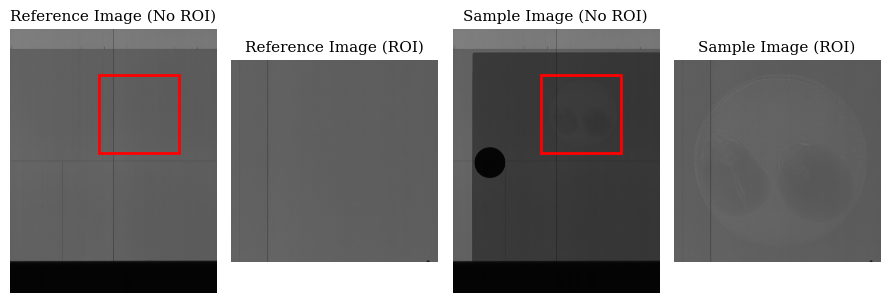

In [6]:
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 4, figsize=(9, 4))

width = x1 - x0
height = y1 - y0

rect1 = patches.Rectangle(
    (x0, y0),
    width, height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

rect2 = patches.Rectangle(
    (x0, y0),
    width, height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

axes[0].imshow(reference_img, cmap="gray")
axes[0].set_title("Reference Image (No ROI)")
axes[0].axis("off")

axes[0].add_patch(rect1)

axes[1].imshow(reference_img_roi, cmap="gray")
axes[1].set_title("Reference Image (ROI)")
axes[1].axis("off")

axes[2].imshow(sample_img, cmap="gray")
axes[2].set_title("Sample Image (No ROI)")
axes[2].axis("off")

axes[2].add_patch(rect2)

axes[3].imshow(sample_img_roi, cmap="gray")
axes[3].set_title("Sample Image (ROI)")
axes[3].axis("off")

fig.tight_layout()

In [7]:
fig.savefig(path2exp / "raw_and_roi_images.png")

### ROI extraction for the dark and  image

For consistency, the same ROI must be applied to the reference, dark and bright images. This ensures identical support in both sample and reference datasets.

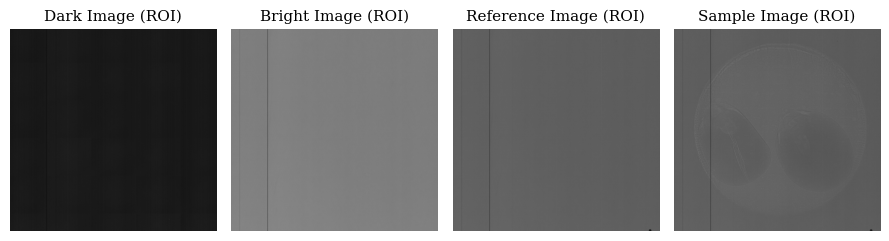

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(9, 4))

axes[0].imshow(dark_img_roi, cmap="gray")
axes[0].set_title("Dark Image (ROI)")
axes[0].axis("off")

axes[1].imshow(bright_img_roi, cmap="gray")
axes[1].set_title("Bright Image (ROI)")
axes[1].axis("off")

axes[2].imshow(reference_img_roi, cmap="gray")
axes[2].set_title("Reference Image (ROI)")
axes[2].axis("off")

axes[3].imshow(sample_img_roi, cmap="gray")
axes[3].set_title("Sample Image (ROI)")
axes[3].axis("off")

fig.tight_layout()

In [9]:
fig.savefig(path2exp / "roi_images.png")

## Flat-field correction (FFC) and analysis of FFC

In [11]:
# SHIMEXPY: main processing functions
from shimexpy import ffc
import time

time0 = time.time()
reference_ffc = ffc(reference_img_roi, dark_img_roi, bright_img_roi)
time1 = time.time()
t_ref_ffc = time1 - time0

time0 = time.time()
sample_ffc = ffc(sample_img_roi, dark_img_roi, bright_img_roi)
time1 = time.time()
t_smp_ffc = time1 - time0

## Fourier transform

#### `shi_fft()`

The function `shi_fft()` returns a `FFTResult` dataclass.  
The attribute `fft` contains the Fourier transform of the input array, while `kx` and `ky` correspond to the spatial frequency coordinates along the horizontal and vertical directions, respectively.

In [12]:
from shimexpy import shi_fft

fft_ref_viz = shi_fft(reference_ffc, projected_grid=5, logspect=True)  # Note that parameter logspect was specified
fft_smp_viz = shi_fft(sample_ffc, projected_grid=5, logspect=True)  # Note that parameter logspect was specified

In [13]:
type(fft_ref_viz)

shimexpy.core.spatial_harmonics.FFTResult

In [14]:
print(type(fft_ref_viz.fft), type(fft_ref_viz.ky), type(fft_ref_viz.kx))

<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [15]:
print(fft_ref_viz.fft.shape, fft_ref_viz.ky.shape, fft_ref_viz.kx.shape)

(1745, 1782) (1745,) (1782,)


## Harmonic extraction and labeling

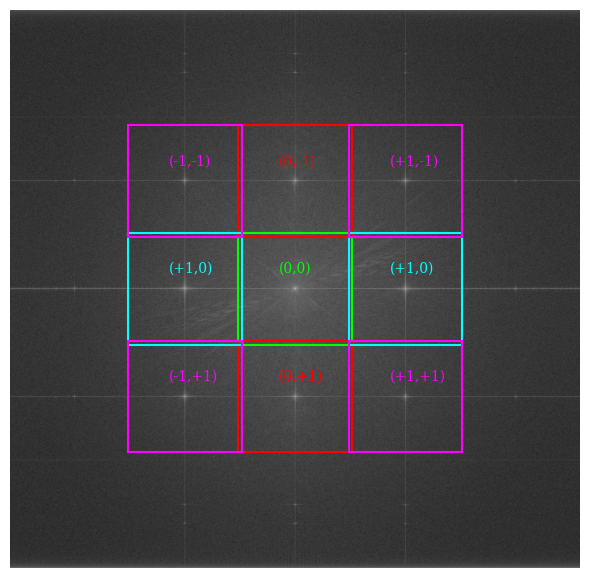

In [17]:
# ============================================================
# FFT + Harmonic Extraction + Visualization (2×4 grid)
# ============================================================
from shimexpy import spatial_harmonics_of_fourier_spectrum


def draw_harmonic_blocks(ax, fft_data, ref_block_grid, HARMONICS):
    """Internal helper to draw FFT + rectangles + labels."""
    ax.imshow(np.abs(fft_data), cmap="gray")
    ax.axis("off")

    for hname, (top, bottom, left, right) in ref_block_grid.items():
        rect = plt.Rectangle(
            (left, top),
            right - left,
            bottom - top,
            fill=False,
            edgecolor=HARMONICS[hname][1],
            linewidth=1.5,
        )
        ax.add_patch(rect)
        ax.text(
            (left + right) // 2 - 50,
            (top + bottom) // 2 - 50,
            HARMONICS[hname][0],
            color=HARMONICS[hname][1],
            fontsize=10
        )

def plot_fft_with_harmonic_rectangles(
    fft_ref_auto,
    fft_smp_auto,
    ref_block_grid,
    HARMONICS
):
    """Plot the FFT with harmonic rectangles for reference and sample."""

    fig_fft, ax_fft = plt.subplots(1, 2, figsize=(12, 6))

    draw_harmonic_blocks(ax_fft[0], fft_ref_auto.fft, ref_block_grid, HARMONICS)
    draw_harmonic_blocks(ax_fft[1], fft_smp_auto.fft, ref_block_grid, HARMONICS)

    fig_fft.tight_layout()
    return fig_fft, ax_fft

# --- Compute FFT of the reference image ---
fft_ref = shi_fft(reference_ffc, projected_grid=5)  # Note that parameter logspect was not specified
fft_smp = shi_fft(sample_ffc, projected_grid=5)  # Note that parameter logspect was not specified

# --- Extract the spatial harmonics automatically ---
time0 = time.time()
ref_harmonics, ref_block_grid = spatial_harmonics_of_fourier_spectrum(
    fft_ref.fft,
    fft_ref.ky,
    fft_ref.kx,
    reference=True
)
time1 = time.time()
t_ref_harm = time1 - time0

time0 = time.time()
smp_harmonics, smp_block_grid = spatial_harmonics_of_fourier_spectrum(
    fft_ref.fft,
    fft_ref.ky,
    fft_ref.kx,
    reference=True
)
time1 = time.time()
t_smp_harm = time1 - time0

# ------------------------------------------------------------
# Plot the FFT with rectangles marking each harmonic region
# ------------------------------------------------------------
HARMONICS = {
    "harmonic_00": ["(0,0)", "lime"],
    "harmonic_diagonal_p1_p1": ["(+1,+1)", "magenta"],
    "harmonic_diagonal_n1_p1": ["(-1,+1)", "magenta"],
    "harmonic_diagonal_n1_n1": ["(-1,-1)", "magenta"],
    "harmonic_diagonal_p1_n1": ["(+1,-1)", "magenta"],
    "harmonic_vertical_positive": ["(0,+1)", "red"],
    "harmonic_vertical_negative": ["(0,-1)", "red"],
    "harmonic_horizontal_positive": ["(+1,0)", "cyan"],
    "harmonic_horizontal_negative": ["(+1,0)", "cyan"]
}

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
draw_harmonic_blocks(ax, fft_smp_viz.fft, ref_block_grid, HARMONICS)
fig.tight_layout()

In [23]:
fig.savefig(path2exp / "fft_ffc_roi_images_smp.png")

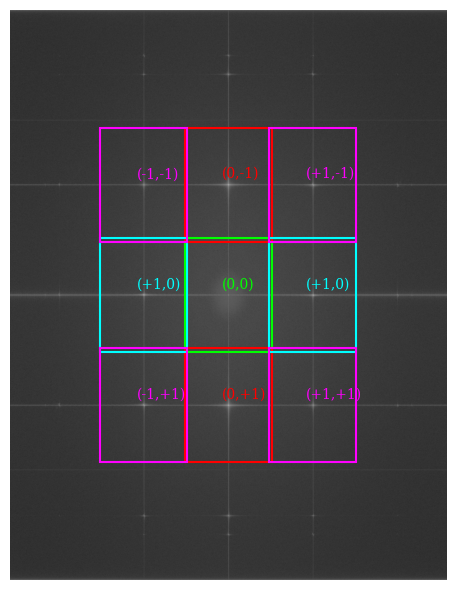

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
draw_harmonic_blocks(ax, fft_ref_viz.fft, ref_block_grid, HARMONICS)
fig.tight_layout()

In [25]:
fig.savefig(path2exp / "fft_ffc_roi_images_ref.png")

In [26]:
import time
import pandas as pd
from shimexpy import get_harmonics, get_contrasts


try:
    import cupy as cp
    USE_GPU = True
except ImportError:
    USE_GPU = False

def gpu_available():
    try:
        _ = cp.cuda.runtime.getDeviceCount()
        return True
    except:
        return False

USE_GPU = gpu_available()


y0, x0 = 600, 1200
Ymax, Xmax = reference_img.shape
fractions = np.round(np.linspace(0.1, 1.0, 10), 2)
roi_bounds = []

results = []
N_REPEATS = 5

for f in fractions:
    height = int((Ymax - y0) * f)
    width  = int((Xmax - x0) * f)

    y1 = y0 + height
    x1 = x0 + width

    roi_bounds.append((y0, y1, x0, x1))


def synchronize_if_gpu():
    if USE_GPU:
        cp.cuda.Device().synchronize()


def run_pipeline(reference_img, sample_img, bright_img, dark_img, bounds):

    y0, y1, x0, x1 = bounds

    reference_roi = reference_img[y0:y1, x0:x1]
    sample_roi    = sample_img[y0:y1, x0:x1]
    bright_roi    = bright_img[y0:y1, x0:x1]
    dark_roi      = dark_img[y0:y1, x0:x1]

    reference_ffc = ffc(reference_roi, dark_roi, bright_roi)
    sample_ffc    = ffc(sample_roi, dark_roi, bright_roi)

    ref_abs, ref_scat, ref_dpc, ref_block_grid = get_harmonics(
        reference_ffc,
        projected_grid=5,
        unwrap=None
    )

    contrasts = get_contrasts(
        sample_ffc,
        (ref_abs, ref_scat, ref_dpc),
        ref_block_grid,
        unwrap=None
    )

    return contrasts


for bounds in roi_bounds:

    runtimes = []

    for _ in range(N_REPEATS):

        synchronize_if_gpu()
        start = time.perf_counter()

        run_pipeline(reference_img, sample_img, bright_img, dark_img, bounds)

        synchronize_if_gpu()
        end = time.perf_counter()

        runtimes.append(end - start)

    y0, y1, x0, x1 = bounds
    pixels = (y1 - y0) * (x1 - x0)

    results.append({
        "ROI_bounds (y0, y1, x0, x1)": bounds,
        "Pixels": pixels,
        "Runtime_s": np.mean(runtimes)
    })

df = pd.DataFrame(results)

full_runtime = df["Runtime_s"].max()
df["Speedup_vs_full"] = full_runtime / df["Runtime_s"]

In [27]:
df

,"ROI_bounds (y0, y1, x0, x1)",Pixels,Runtime_s,Speedup_vs_full
0,"(600, 1129, 1200, 1540)",179860,0.246131,19.862961
1,"(600, 1658, 1200, 1881)",720498,0.314465,15.546697
2,"(600, 2187, 1200, 2222)",1621914,0.542057,9.019141
3,"(600, 2716, 1200, 2563)",2884108,0.851984,5.738245
4,"(600, 3245, 1200, 2904)",4507080,1.400029,3.491992
5,"(600, 3774, 1200, 3244)",6487656,1.858630,2.630374
6,"(600, 4302, 1200, 3585)",8829270,2.577798,1.896538
7,"(600, 4832, 1200, 3926)",11536432,3.163723,1.545297
8,"(600, 5361, 1200, 4267)",14601987,4.197634,1.164678
9,"(600, 5890, 1200, 4608)",18028320,4.888891,1.000000


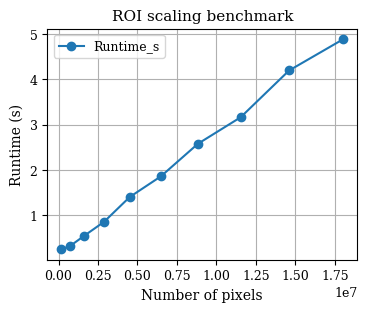

In [28]:
ax = df.plot(
    x="Pixels",
    y="Runtime_s",
    marker="o",
    figsize=(4,3),
    grid=True
)

ax.set_xlabel("Number of pixels")
ax.set_ylabel("Runtime (s)")
ax.set_title("ROI scaling benchmark")

plt.show()

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(path2exp / "runtime_vs_pxs.png", dpi=100)

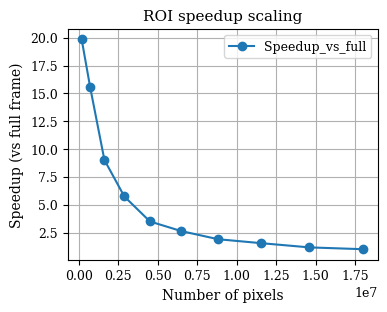

In [29]:
ax = df.plot(
    x="Pixels",
    y="Speedup_vs_full",
    marker="o",
    figsize=(4,3),
    grid=True
)

ax.set_xlabel("Number of pixels")
ax.set_ylabel("Speedup (vs full frame)")
ax.set_title("ROI speedup scaling")

plt.show()

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(path2exp / "speedup_vs_pxs.png", dpi=100)

In [30]:
print(df[["Pixels", "Runtime_s"]])

     Pixels  Runtime_s
0    179860   0.246131
1    720498   0.314465
2   1621914   0.542057
3   2884108   0.851984
4   4507080   1.400029
5   6487656   1.858630
6   8829270   2.577798
7  11536432   3.163723
8  14601987   4.197634
9  18028320   4.888891


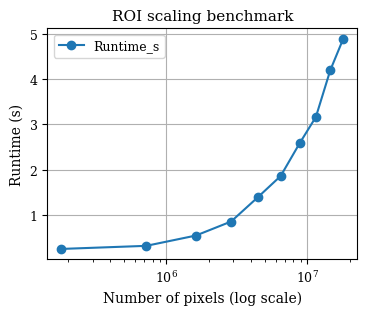

In [31]:
ax = df.plot(
    x="Pixels",
    y="Runtime_s",
    marker="o",
    figsize=(4,3),
    grid=True,
    logx=True
)

ax.set_xlabel("Number of pixels (log scale)")
ax.set_ylabel("Runtime (s)")
ax.set_title("ROI scaling benchmark")

plt.show()

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(path2exp / "runtime_vs_log_pxs.png", dpi=100)

## Reference normalization and contrast reconstruction

### Main Processing Functions in Shimexpy

Shimexpy exposes five high-level processing functions.  
Although they share the same mathematical foundation, each one is designed for a different purpose.  
This section summarizes when to use each function and why multiple options exist.

---

#### 1. `get_harmonics(image, projected_grid, block_grid=None, unwrap=None)`

Purpose:

- Extracts the spatial harmonics from a single image.
- Labels the harmonic components (horizontal, vertical, diagonal, etc.).
- Returns absolute absorption, scattering, and differential phase (not contrast).

Best suited for:

- Preparing the reference image.
- Real-time applications where each frame is processed independently.

---

#### 2. `get_contrast(sample_img, reference, ref_block_grid, type_of_contrast, unwrap=None)`

Purpose:

- Computes one specific contrast relative to its reference.
- Extremely fast; ideal for live visualization or acquisition systems.

Available contrast keys:

- `"absorption"`
- `"horizontal_scattering"`, `"vertical_scattering"`, `"bidirectional_scattering"`
- `"horizontal_phasemap"`, `"vertical_phasemap"`, `"bidirectional_phasemap"`

---

#### 3. `get_contrasts(sample_img, reference_tuple, ref_block_grid, unwrap=None)`

Purpose:

- Computes the three main SHI contrasts in a single call:
  - absorption  
  - bidirectional scattering  
  - bidirectional differential phase  

Advantages:

- Uses the already-computed reference contrasts.
- Faster than recomputing everything from scratch.
- Ideal for workflows where `get_harmonics` has already been applied.

---

#### 4. `get_all_contrasts(sample_img, reference_img, projected_grid, unwrap=None)`

Purpose:

- The most convenient and self-contained function.
- Takes raw sample and reference images as inputs and returns the three contrasts.
- Internally performs the full pipeline:

**Note that all functions include an `unwrap` parameter, which defaults to `None`. Internally, this triggers the use of `skimage.unwrap_phase` to unwrap the differential phase image.**

### *Function description*

--------------------------------------------
**1) get_harmonics**

--------------------------------------------

In [18]:
from shimexpy import get_harmonics

ref_abs, ref_scat, ref_dpc, ref_block_grid = get_harmonics(
    reference_ffc,
    projected_grid=5,
    unwrap=None   # default → skimage.unwrap_phase
)

smp_abs, smp_scat, smp_dpc, smp_block_grid = get_harmonics(
    sample_ffc,
    projected_grid=5,
    unwrap=None   # default → skimage.unwrap_phase
)

In [33]:
print("Reference harmonics")
print("-------------------")
print("Main harmonic", type(ref_abs), ref_abs.shape, ref_abs.dtype)
print("Amplitude", type(ref_scat), ref_scat.shape, ref_scat.dtype)
print("Phase map", type(ref_dpc), ref_dpc.shape, ref_dpc.dtype)

print()

print("Sample harmonics")
print("-------------------")
print("Main harmonic", type(smp_abs), smp_abs.shape, smp_abs.dtype)
print("Amplitude", type(smp_scat),smp_scat.shape, smp_scat.dtype)
print("Phase map", type(smp_dpc), smp_dpc.shape, smp_dpc.dtype)

Reference harmonics
-------------------
Main harmonic <class 'xarray.core.dataarray.DataArray'> (852, 652) float32
Amplitude <class 'xarray.core.dataarray.DataArray'> (8, 852, 652) float32
Phase map <class 'xarray.core.dataarray.DataArray'> (8, 852, 652) complex64

Sample harmonics
-------------------
Main harmonic <class 'xarray.core.dataarray.DataArray'> (852, 652) float32
Amplitude <class 'xarray.core.dataarray.DataArray'> (8, 852, 652) float32
Phase map <class 'xarray.core.dataarray.DataArray'> (8, 852, 652) complex64


In [34]:
grid_pos = {
    "center":                       (1, 1),  # (0, 0)
    "harmonic_horizontal_negative": (1, 0),  # (-1, 0)
    "harmonic_horizontal_positive": (1, 2),  # (+1, 0)
    "harmonic_vertical_positive":   (2, 1),  # (0, +1)
    "harmonic_vertical_negative":   (0, 1),  # (0, -1)
    "harmonic_diagonal_n1_p1":      (2, 0),  # (-1, +1)
    "harmonic_diagonal_p1_p1":      (2, 2),  # (+1, +1)
    "harmonic_diagonal_n1_n1":      (0, 0),  # (-1, -1)
    "harmonic_diagonal_p1_n1":      (0, 2),  # (+1, -1)
}

def plot_realspace_harmonics(abs_img, scat_da, title):
    """
    abs_img : DataArray (y, x)          -> main (0,0)
    scat_da : DataArray (harmonic,y,x)  -> First order labelled
    """
    fig, axes = plt.subplots(3, 3, figsize=(5, 5))
    fig.suptitle(title, fontsize=14)

    r, c = grid_pos["center"]
    axes[r, c].imshow(abs_img.values, cmap="gray")
    axes[r, c].set_title("(0, 0)", fontsize=9)
    axes[r, c].axis("off")

    for hname in scat_da.coords["harmonic"].values:
        if hname not in grid_pos:
            continue
        r, c = grid_pos[hname]
        img = scat_da.sel(harmonic=hname).values
        axes[r, c].imshow(percentile_eq(img), cmap="gray")
        # etiqueta corta
        label = {
            "harmonic_horizontal_negative": "(-1, 0)",
            "harmonic_horizontal_positive": "(+1, 0)",
            "harmonic_vertical_positive":   "(0, +1)",
            "harmonic_vertical_negative":   "(0, -1)",
            "harmonic_diagonal_n1_p1":      "(-1, +1)",
            "harmonic_diagonal_p1_p1":      "(+1, +1)",
            "harmonic_diagonal_n1_n1":      "(-1, -1)",
            "harmonic_diagonal_p1_n1":      "(+1, -1)",
        }[hname]
        axes[r, c].set_title(label, fontsize=9)
        axes[r, c].axis("off")

    fig.tight_layout()

    return fig

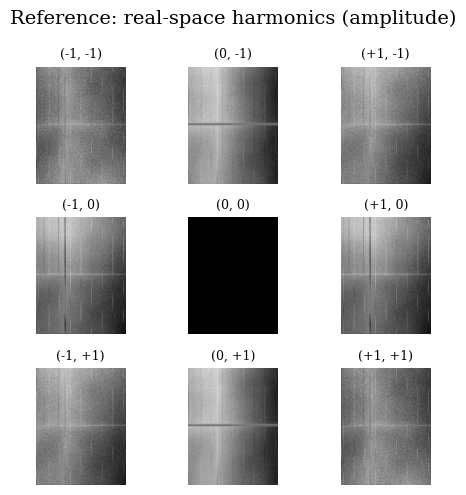

In [35]:
# --- Llamada para referencia y muestra ---
import xarray as xr

fig = plot_realspace_harmonics(xr.zeros_like(ref_abs), ref_scat, "Reference: real-space harmonics (amplitude)")
fig.savefig(path2exp / "ref_harmonic_amplitude.png")

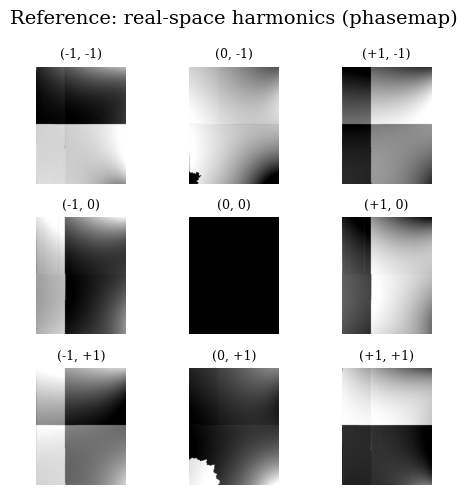

In [36]:
fig = plot_realspace_harmonics(xr.zeros_like(ref_abs), ref_dpc, "Reference: real-space harmonics (phasemap)")
fig.savefig(path2exp / "ref_harmonic_phasemap.png")

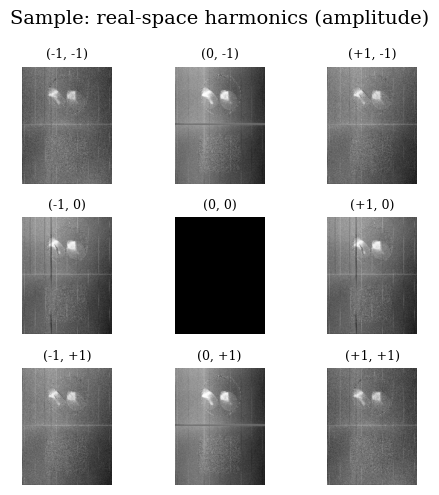

In [37]:
fig = plot_realspace_harmonics(xr.zeros_like(smp_abs), smp_scat, "Sample: real-space harmonics (amplitude)")
fig.savefig(path2exp / "smp_harmonic_amplitude.png")

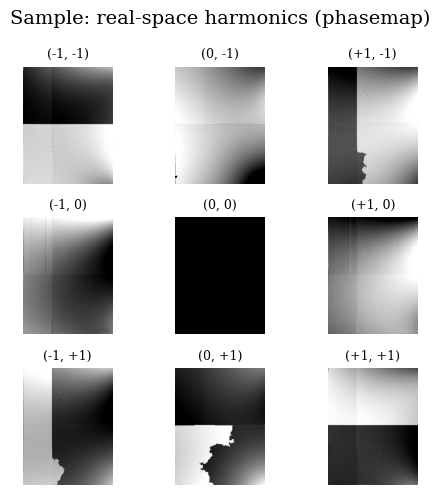

In [38]:
fig = plot_realspace_harmonics(xr.zeros_like(smp_abs), smp_dpc, "Sample: real-space harmonics (phasemap)")
fig.savefig(path2exp / "smp_harmonic_phasemap.png")

--------------------------------------------
**2) get_contrast (single contrast, real-time)**

--------------------------------------------

In [39]:
from shimexpy import get_contrast

# Absorption contrast image
single_abs = get_contrast(sample_ffc, ref_abs , ref_block_grid, "absorption")

# Horizontal, vertical and bidirectional scattering contrast images
single_hsc = get_contrast(sample_ffc, ref_scat, ref_block_grid, "horizontal_scattering")
single_vsc = get_contrast(sample_ffc, ref_scat, ref_block_grid, "vertical_scattering")
single_bsc = get_contrast(sample_ffc, ref_scat, ref_block_grid, "bidirectional_scattering")

# Horizontal, vertical and bidirectional differential phase contrast images
single_hdp = get_contrast(sample_ffc, ref_dpc , ref_block_grid, "horizontal_phasemap")
single_vdp = get_contrast(sample_ffc, ref_dpc , ref_block_grid, "vertical_phasemap")
single_bdp = get_contrast(sample_ffc, ref_dpc , ref_block_grid, "bidirectional_phasemap")

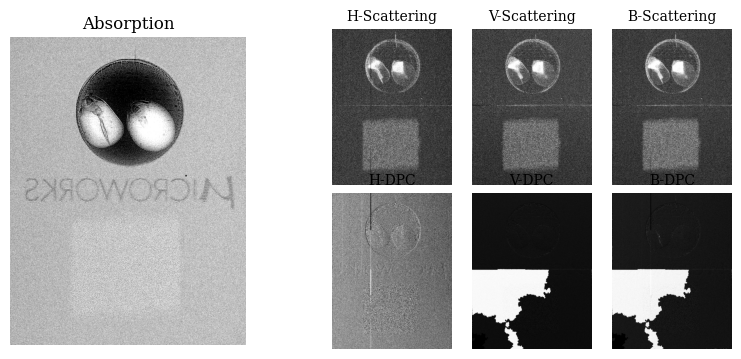

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Helper for display normalization
def eq(x):
    p2, p98 = np.percentile(x, (2, 98))
    return np.clip((x - p2) / (p98 - p2 + 1e-9), 0, 1)

# -----------------------------------------------------------
# Data to display
# -----------------------------------------------------------
abs_img = single_abs

scat_imgs = [single_hsc, single_vsc, single_bsc]
scat_titles = ["H-Scattering", "V-Scattering", "B-Scattering"]

dpc_imgs  = [single_hdp, single_vdp, single_bdp]
dpc_titles = ["H-DPC", "V-DPC", "B-DPC"]

# -----------------------------------------------------------
# Figure layout
# -----------------------------------------------------------
fig = plt.figure(figsize=(9, 4))

# LEFT PANEL: single absorption
ax_abs = fig.add_subplot(1, 2, 1)
ax_abs.imshow(eq(abs_img), cmap="gray")
ax_abs.set_title("Absorption", fontsize=12)
ax_abs.axis("off")

# RIGHT PANEL: 2 × 3 grid for scattering + DPC
grid = fig.add_gridspec(2, 3, left=0.52, right=0.98, top=0.9, bottom=0.1, wspace=0.05, hspace=0.05)

axes_right = []
for i in range(2):
    for j in range(3):
        axes_right.append(fig.add_subplot(grid[i, j]))

# -----------------------------------------------------------
# Fill the grid
#   Row 1 -> scattering  (3 images)
#   Row 2 -> DPC         (3 images)
# -----------------------------------------------------------
for ax, img, title in zip(axes_right[:3], scat_imgs, scat_titles):
    ax.imshow(eq(img), cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

for ax, img, title in zip(axes_right[3:], dpc_imgs, dpc_titles):
    ax.imshow(eq(img), cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

In [41]:
fig.savefig(path2exp / "abs_and_directional_contrasts.png")

--------------------------------------------
**3) get_contrasts (main 3 contrasts)**

--------------------------------------------

In [19]:
from shimexpy import get_contrasts

abs_contrast, scat_contrast, dpc_contrast = get_contrasts(
    sample_ffc,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid,
    unwrap="snaphu"
)

/home/beltran/venvs/base/lib/python3.12/site-packages/dask/array/utils.py:105: ComplexWarning: Casting complex values to real discards the imaginary part
  meta = meta.astype(dtype)



snaphu v2.0.7
22 parameters input from file /tmp/tmpi2r9kdf4/snaphu.config.ygv3otrc.txt (22 lines total)

snaphu v2.0.7
22 parameters input from file /tmp/tmpx5vap901/snaphu.config.ofur90j_.txt (22 lines total)

snaphu v2.0.7
22 parameters input from file /tmp/tmp8j1otcq9/snaphu.config.ecoygfog.txt (22 lines total)

snaphu v2.0.7
22 parameters input from file /tmp/tmpsufoo77x/snaphu.config.zne9wc5q.txt (22 lines total)
Reading wrapped phase from file /tmp/tmpi2r9kdf4/snaphu.igram.o5_tsj_3.c8
No weight file specified.  Assuming uniform weights
Reading correlation data from file /tmp/tmpi2r9kdf4/snaphu.corr.5764nsql.f4
Calculating smooth-solution cost parameters
Initializing flows with MCF algorithm
Running nonlinear network flow optimizer
Maximum flow on network: 1
Flow increment: 1  (Total improvements: 0)
Found 1 valid set(s) of connected nodes
Reading wrapped phase from file /tmp/tmp8j1otcq9/snaphu.igram.dnjcq7q4.c8
No weight file specified.  Assuming uniform weights
Reading correla

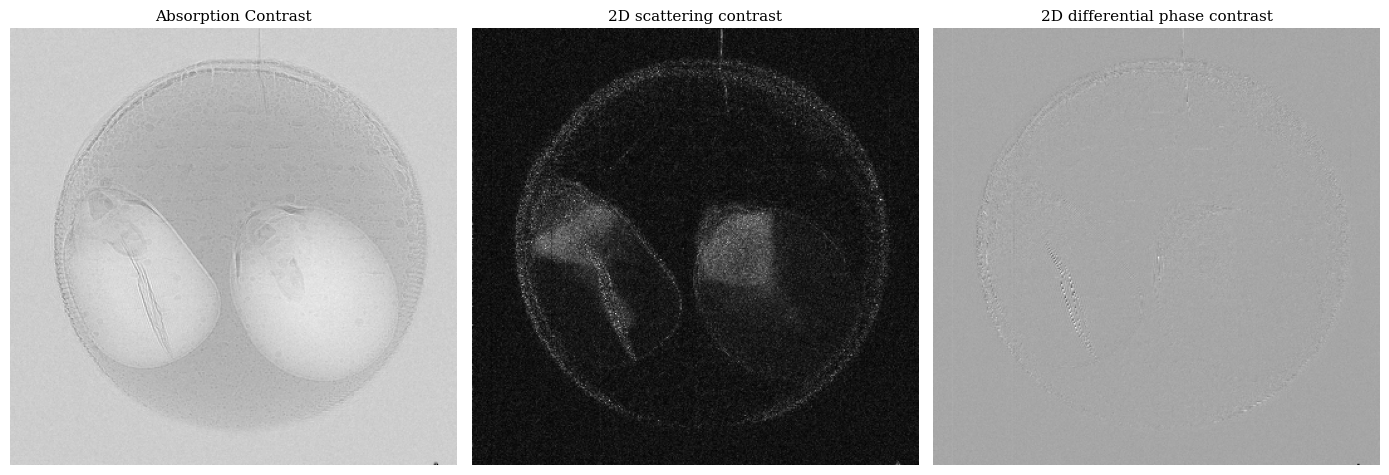

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 8))

axes[0].imshow(abs_contrast, cmap="gray")
axes[0].set_title("Absorption Contrast")
axes[0].axis("off")

axes[1].imshow(scat_contrast, cmap="gray")
axes[1].set_title("2D scattering contrast")
axes[1].axis("off")

axes[2].imshow(dpc_contrast, cmap="gray")
axes[2].set_title("2D differential phase contrast")
axes[2].axis("off")

fig.tight_layout()

In [40]:
fig.savefig(path2exp / "contrasts.png")

--------------------------------------------
**4) get_all_contrasts**

--------------------------------------------

In [21]:
from shimexpy import get_all_contrasts

abs_c, scat_c, dpc_c = get_all_contrasts(
    sample_ffc,
    reference_ffc,
    projected_grid=5,
    unwrap=None
)

In [22]:
fig = plot_realspace_harmonics(xr.zeros_like(abs_c), scat_c, "")
fig.savefig(path2exp / "all_scattering_contrast.png")

NameError: name 'plot_realspace_harmonics' is not defined

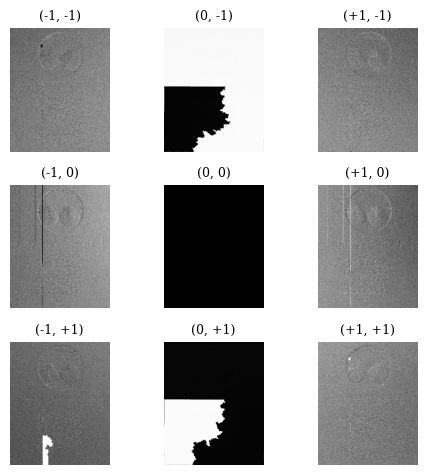

In [43]:
fig = plot_realspace_harmonics(xr.zeros_like(abs_c), dpc_c, "")
fig.savefig(path2exp / "all_dpc_contrast.png")

--------------------------------------------
**5) get_all_harmonic_contrasts**

--------------------------------------------

In [44]:
from shimexpy import get_all_harmonic_contrasts

harmonic_contrasts = get_all_harmonic_contrasts(
    sample_ffc,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid,
    unwrap=None
)

In [45]:
type(harmonic_contrasts)

xarray.core.dataarray.DataArray

In [46]:
harmonic_contrasts

<xarray.DataArray (contrast: 7, y: 824, x: 662)> Size: 31MB
dask.array<concatenate, shape=(7, 824, 662), dtype=complex64, chunksize=(1, 824, 662), chunktype=numpy.ndarray>
Coordinates:
  * contrast  (contrast) <U24 672B 'absorption' ... 'diff_phase_bidirectional'
Dimensions without coordinates: y, x

### Reproducibility

This notebook is fully reproducible on any Linux, macOS or Windows machine  
supporting Python 3.10+, NumPy, CuPy (optional), Dask and Matplotlib.  
All datasets are included in the Zenodo record associated with the publication.